# EDA (탐색적 데이터 분석 - Exploratory Data Analysis)

확인할 내용:
1. 데이터 로딩 & 기본 정보 확인
2. 결측치(빈 값) 분석
3. 수치형 변수 분포
4. 범주형 변수 분포
5. 타겟 변수(stress_score) 분석
6. 변수 간 상관관계

## 1-1. 라이브러리 불러오기 & 데이터 로딩

In [ ]:
# 데이터 분석에 필요한 라이브러리
import pandas as pd    # 데이터프레임(표 형태) 처리
import numpy as np     # 수치 연산
import matplotlib.pyplot as plt  # 그래프 그리기
import seaborn as sns  # 예쁜 통계 그래프
import yaml            # config.yaml 읽기
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 숨기기

# 그래프 스타일 설정
sns.set_style('whitegrid')

# 그래프 한글 깨짐 방지 (Mac 기준)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료!')

라이브러리 로딩 완료!


In [21]:
# 각 라이브러리가 정상적으로 작동하는지 버전 확인
print(f"Pandas 버전: {pd.__version__}")
print(f"Numpy 버전: {np.__version__}")
print(f"Seaborn 버전: {sns.__version__}")
print(f"Matplotlib 버전: {plt.matplotlib.__version__}")
print(f"PyYAML 버전: {yaml.__version__}")

Pandas 버전: 2.2.3
Numpy 버전: 1.26.4
Seaborn 버전: 0.13.2
Matplotlib 버전: 3.9.2
PyYAML 버전: 6.0.2


In [2]:
# config.yaml에서 경로 정보 읽기
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# 데이터 파일 경로 조합
raw_dir = f"../{config['data']['raw_dir']}"
train_path = f"{raw_dir}/{config['data']['train_file']}"
test_path = f"{raw_dir}/{config['data']['test_file']}"

# CSV 파일 읽기
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f'Train 데이터: {train.shape[0]}행 x {train.shape[1]}열')
print(f'Test 데이터:  {test.shape[0]}행 x {test.shape[1]}열')

Train 데이터: 3000행 x 18열
Test 데이터:  3000행 x 17열


## 1-2. 데이터 기본 정보 확인

데이터의 첫 몇 행을 보고, 각 컬럼의 타입과 전체적인 통계를 파악합니다.

In [3]:
# 처음 5행 확인 - 데이터가 어떻게 생겼는지 감을 잡기 위함
train.head()

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,NaN,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,NaN,diabetes,normal,graduate degree,NaN,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,NaN,NaN,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,NaN,oversleeping,graduate degree,NaN,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,NaN,0.36


In [4]:
# 각 컬럼의 데이터 타입과 null이 아닌 개수 확인
# - object: 문자열(범주형)
# - int64/float64: 숫자(수치형)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

In [ ]:
# 수치형 변수의 기본 통계량
# count: 값이 있는 개수
# mean: 평균
# std: 표준편차
# min/25%/50%/75%/max: 최소~최대 분포
train.describe()

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,1968.000000,3000.000000
mean,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,8.716972,0.482130
std,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,1.628944,0.288252
min,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,4.000000,0.000000
25%,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,8.000000,0.230000
50%,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,9.000000,0.480000
75%,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,10.000000,0.730000
max,89.00000,195.280000,120.880000,313.350000,191.000000,124.000000,185.740000,2.000000,16.000000,1.000000


In [ ]:
# 범주형 변수의 기본 통계량
# count: 값이 있는 개수
# unique: 고유값 수
# top: 가장 많은 값
# freq: 가장 많은 값의 빈도
train.describe(include='object')

,ID,gender,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level
count,3000,3000,3000,3000,1711,1514,3000,2393
unique,3000,2,3,3,3,3,3,3
top,TRAIN_0000,F,moderate,ex-smoker,high blood pressure,diabetes,normal,high school diploma
freq,1,1508,1431,1177,697,615,1557,924


In [8]:
train.describe(include='all')

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
count,3000,3000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000,1711,1514,3000,2393,1968.000000,3000.000000
unique,3000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3,3,3,3,NaN,NaN
top,TRAIN_0000,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,moderate,ex-smoker,high blood pressure,diabetes,normal,high school diploma,NaN,NaN
freq,1,1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1431,1177,697,615,1557,924,NaN,NaN
mean,NaN,NaN,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,NaN,NaN,NaN,NaN,NaN,NaN,8.716972,0.482130
std,NaN,NaN,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,NaN,NaN,NaN,NaN,NaN,NaN,1.628944,0.288252
min,NaN,NaN,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,0.000000
25%,NaN,NaN,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,0.230000
50%,NaN,NaN,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,0.480000
75%,NaN,NaN,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,0.730000


## 1-3. 결측치(빈 값) 분석

결측치가 있으면 모델 학습에 문제가 생길 수 있습니다.  
어떤 컬럼에 얼마나 비어있는지 확인합니다.

In [9]:
# Train 결측치 현황
train_missing = train.isnull().sum()  # 컬럼별 결측치 개수
train_missing_pct = (train_missing / len(train) * 100).round(2)  # 비율(%)

missing_df = pd.DataFrame({
    '결측치 수': train_missing,
    '비율(%)': train_missing_pct
})

# 결측치가 있는 컬럼만 표시
missing_df[missing_df['결측치 수'] > 0].sort_values('비율(%)', ascending=False)

,결측치 수,비율(%)
family_medical_history,1486,49.53
medical_history,1289,42.97
mean_working,1032,34.40
edu_level,607,20.23


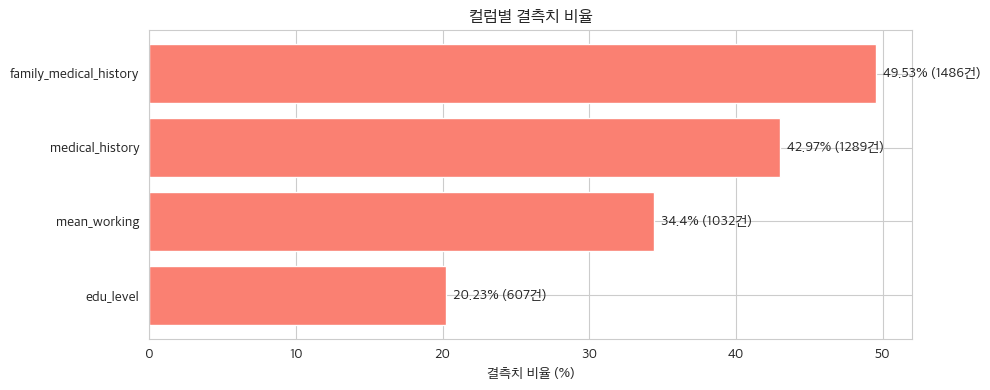

In [ ]:
# 결측치 시각화 - 한눈에 보기
missing_cols = missing_df[missing_df['결측치 수'] > 0].sort_values('비율(%)', ascending=True)

if len(missing_cols) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_cols) * 0.5)))
    ax.barh(missing_cols.index, missing_cols['비율(%)'], color='salmon')
    ax.set_xlabel('결측치 비율 (%)')
    ax.set_title('컬럼별 결측치 비율')
    
    # 막대 옆에 수치 표시
    for i, (val, cnt) in enumerate(zip(missing_cols['비율(%)'], missing_cols['결측치 수'])):
        ax.text(val + 0.5, i, f'{val}% ({int(cnt)}건)', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print('결측치가 없습니다!')

In [11]:
# Test 데이터도 동일하게 결측치 확인
test_missing = test.isnull().sum()
test_missing_pct = (test_missing / len(test) * 100).round(2)

test_missing_df = pd.DataFrame({
    '결측치 수': test_missing,
    '비율(%)': test_missing_pct
})

print('=== Test 데이터 결측치 ===')
test_missing_df[test_missing_df['결측치 수'] > 0].sort_values('비율(%)', ascending=False)

=== Test 데이터 결측치 ===


,결측치 수,비율(%)
family_medical_history,1416,47.20
medical_history,1309,43.63
mean_working,1008,33.60
edu_level,647,21.57


## 1-4. 수치형 변수 분포 확인

각 숫자 컬럼의 분포를 히스토그램으로 시각화합니다.  
- **정규분포에 가까운지** (종 모양)
- **이상치(극단적으로 크거나 작은 값)가 있는지** 확인

### 결측치 존재
1주일당 평균 근로 시간(mean_working)의 결측치 : 607개 (20.23%)

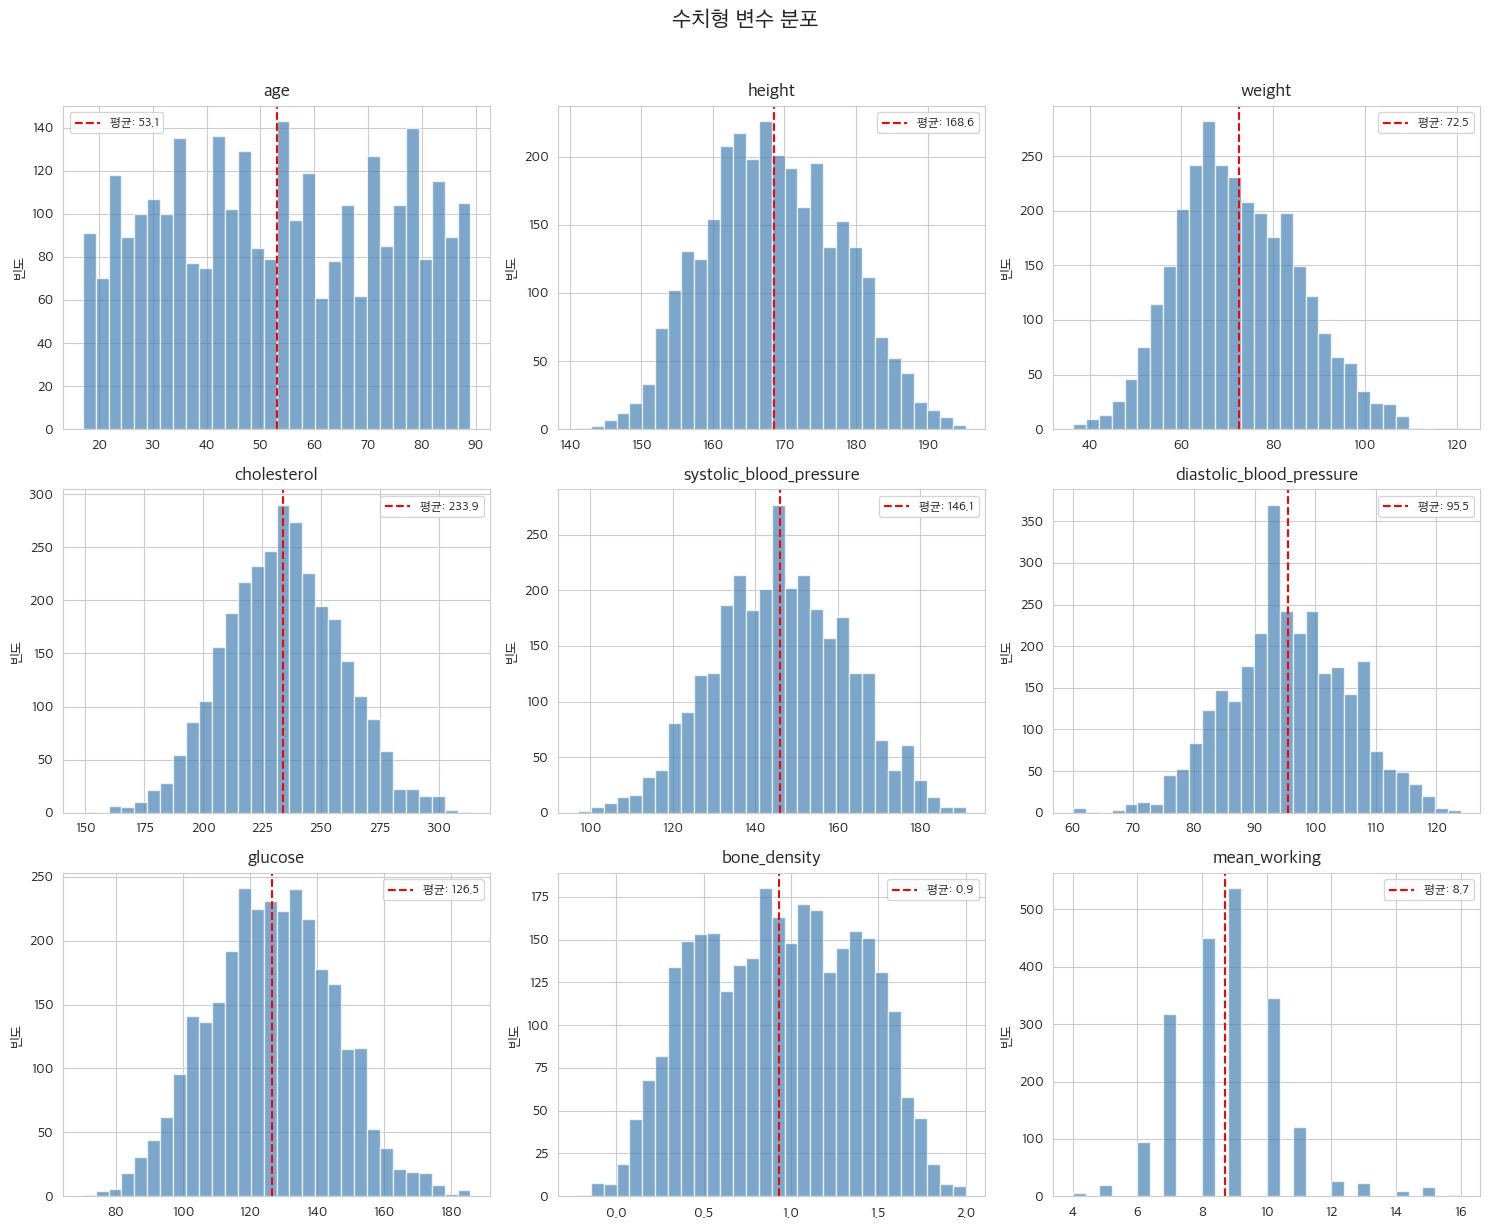

In [12]:
# config에서 수치형 변수 목록 가져오기
num_cols = config['features']['numerical']

# 수치형 변수별 히스토그램
n_cols = 3  # 한 행에 3개씩
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # 필요한 행 수 계산

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()  # 2차원 배열을 1차원으로 펼치기

for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_ylabel('빈도')
    
    # 평균선 표시
    mean_val = train[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'평균: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

# 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 변수 분포', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 히스토그램 분석
- 분석 방법: 
  1. 데이터의 모양을 확인.
  2. 평균을 중심으로 모양이 어떻게 분포되었는지 확인

- 분석 결과
  1. 평균을 중심으로 좌우로 퍼지는 산모양인 정규분포 모양 : 키, 몸무게, 콜레스테롤 수치, 수축기 혈압, 이완기 혈압, 혈당 수치, 골밀도
  2. 균등한 분포를 모양 : 나이 -> 연령에 치우지지 않아 연령대별 스트레스 차이를 분석할 수 있다.
  3. 이산형 형태 : 1주일당 평균 근로 시간
  * 이산형 : 데이터나 변수가 서로 연결되지 않고, 분리되어 있거나 개수를 셀 수 있는 뚜렷한 값(정수형)을 갖는 형태 

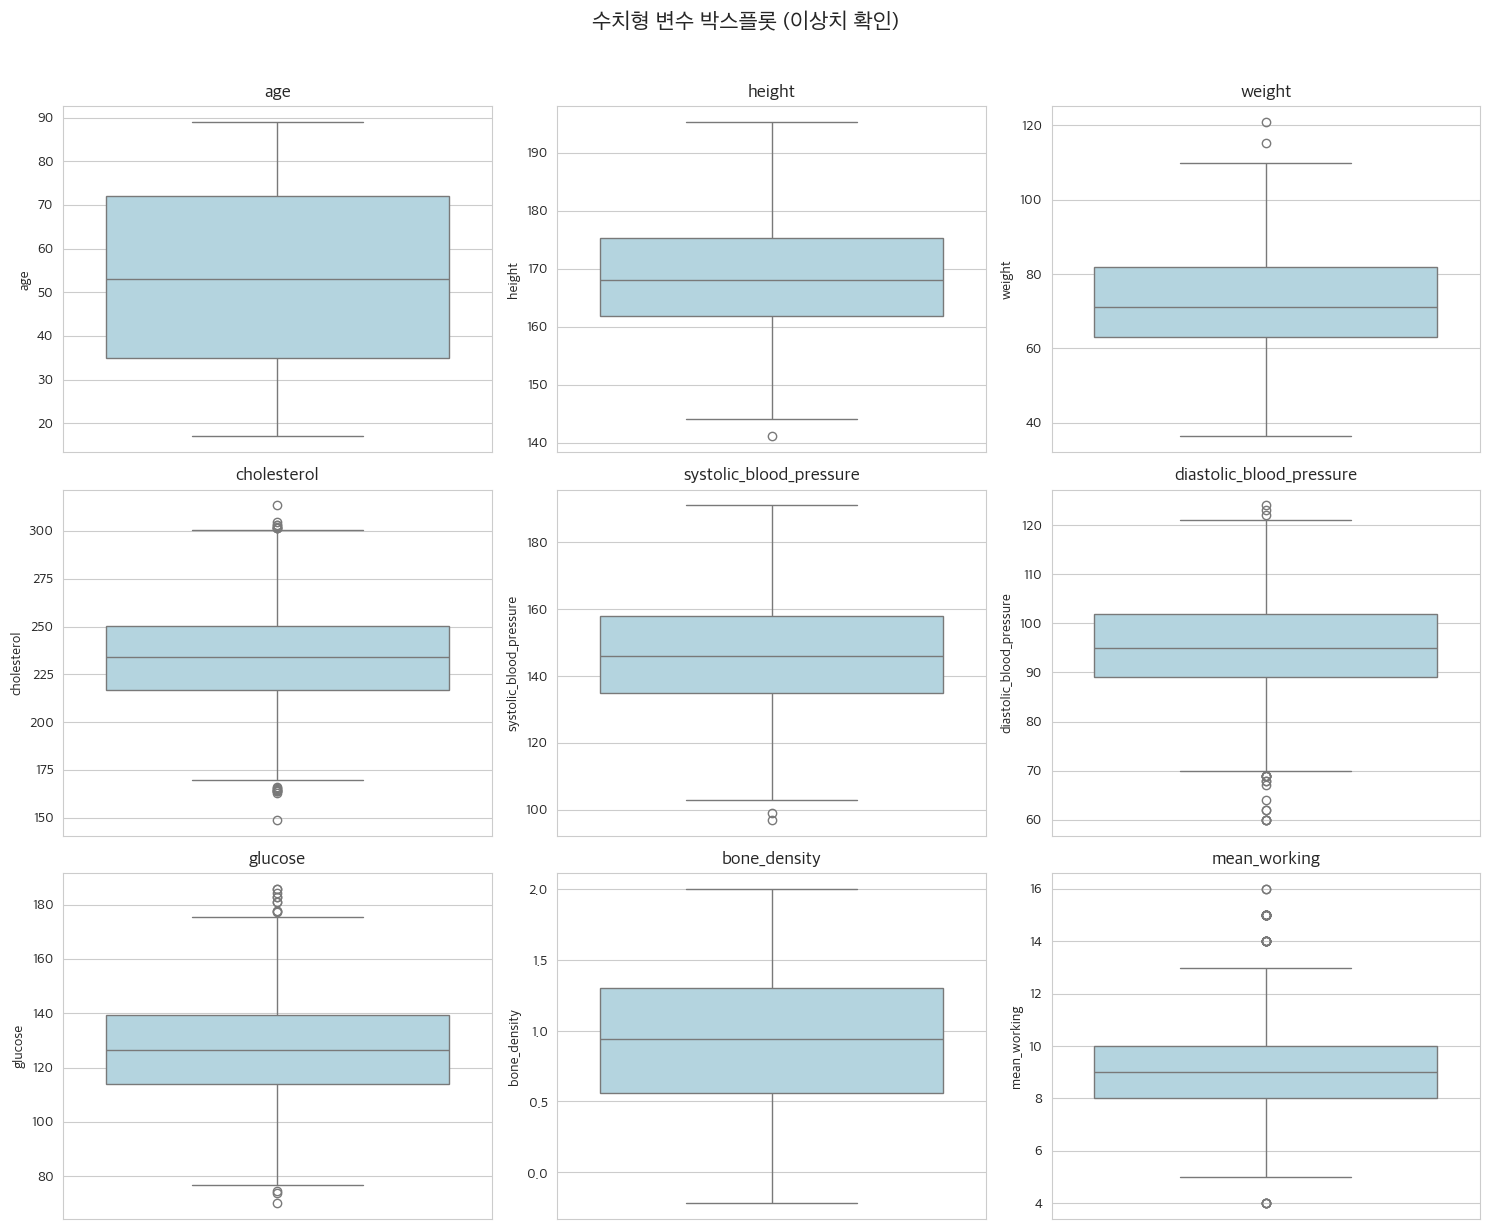

In [13]:
# 박스플롯 - 이상치 확인에 좋음
# 상자 바깥의 점들이 이상치(outlier)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'{col}', fontsize=13)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 변수 박스플롯 (이상치 확인)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 박스플롯 분석
- 분석 방법: 
  1. 네모 상자 : 전체 데이터의 중간 50%가 모이는 곳
  2. 상자 안 선 : 중앙값
  3. 선 외의 동그라미 : 이상치(평균에서 멀리 떨어져 있는 것)

- 분석 결과
  1. 이상치가 없는 깔끔한 변수 : 연령, 골밀도
  2. 이상치가 존재하는 변수 : 키, 몸무게, 콜레스테롤 수치, 수축기 혈압, 이완기 혈압, 혈당 수치, 1주일당 평균 근로 시간
  3. 단방향 이상치
    - 아래 : 키, 수축기 혈압
    - 위 : 몸무게

## 1-5. 범주형 변수 분포 확인

문자열로 된 변수들의 각 카테고리별 개수를 막대 그래프로 확인합니다.  
- 특정 카테고리에 **데이터가 편중**되어 있는지
- 어떤 **고유값들이 존재**하는지 파악합니다.

In [14]:
# config에서 범주형 변수 목록 가져오기
cat_cols = config['features']['categorical']

# 각 범주형 변수의 고유값 확인
for col in cat_cols:
    unique_vals = train[col].dropna().unique()
    print(f'{col}: {len(unique_vals)}개 → {sorted(unique_vals)}')

gender: 2개 → ['F', 'M']
activity: 3개 → ['intense', 'light', 'moderate']
smoke_status: 3개 → ['current-smoker', 'ex-smoker', 'non-smoker']
medical_history: 3개 → ['diabetes', 'heart disease', 'high blood pressure']
family_medical_history: 3개 → ['diabetes', 'heart disease', 'high blood pressure']
sleep_pattern: 3개 → ['normal', 'oversleeping', 'sleep difficulty']
edu_level: 3개 → ['bachelors degree', 'graduate degree', 'high school diploma']


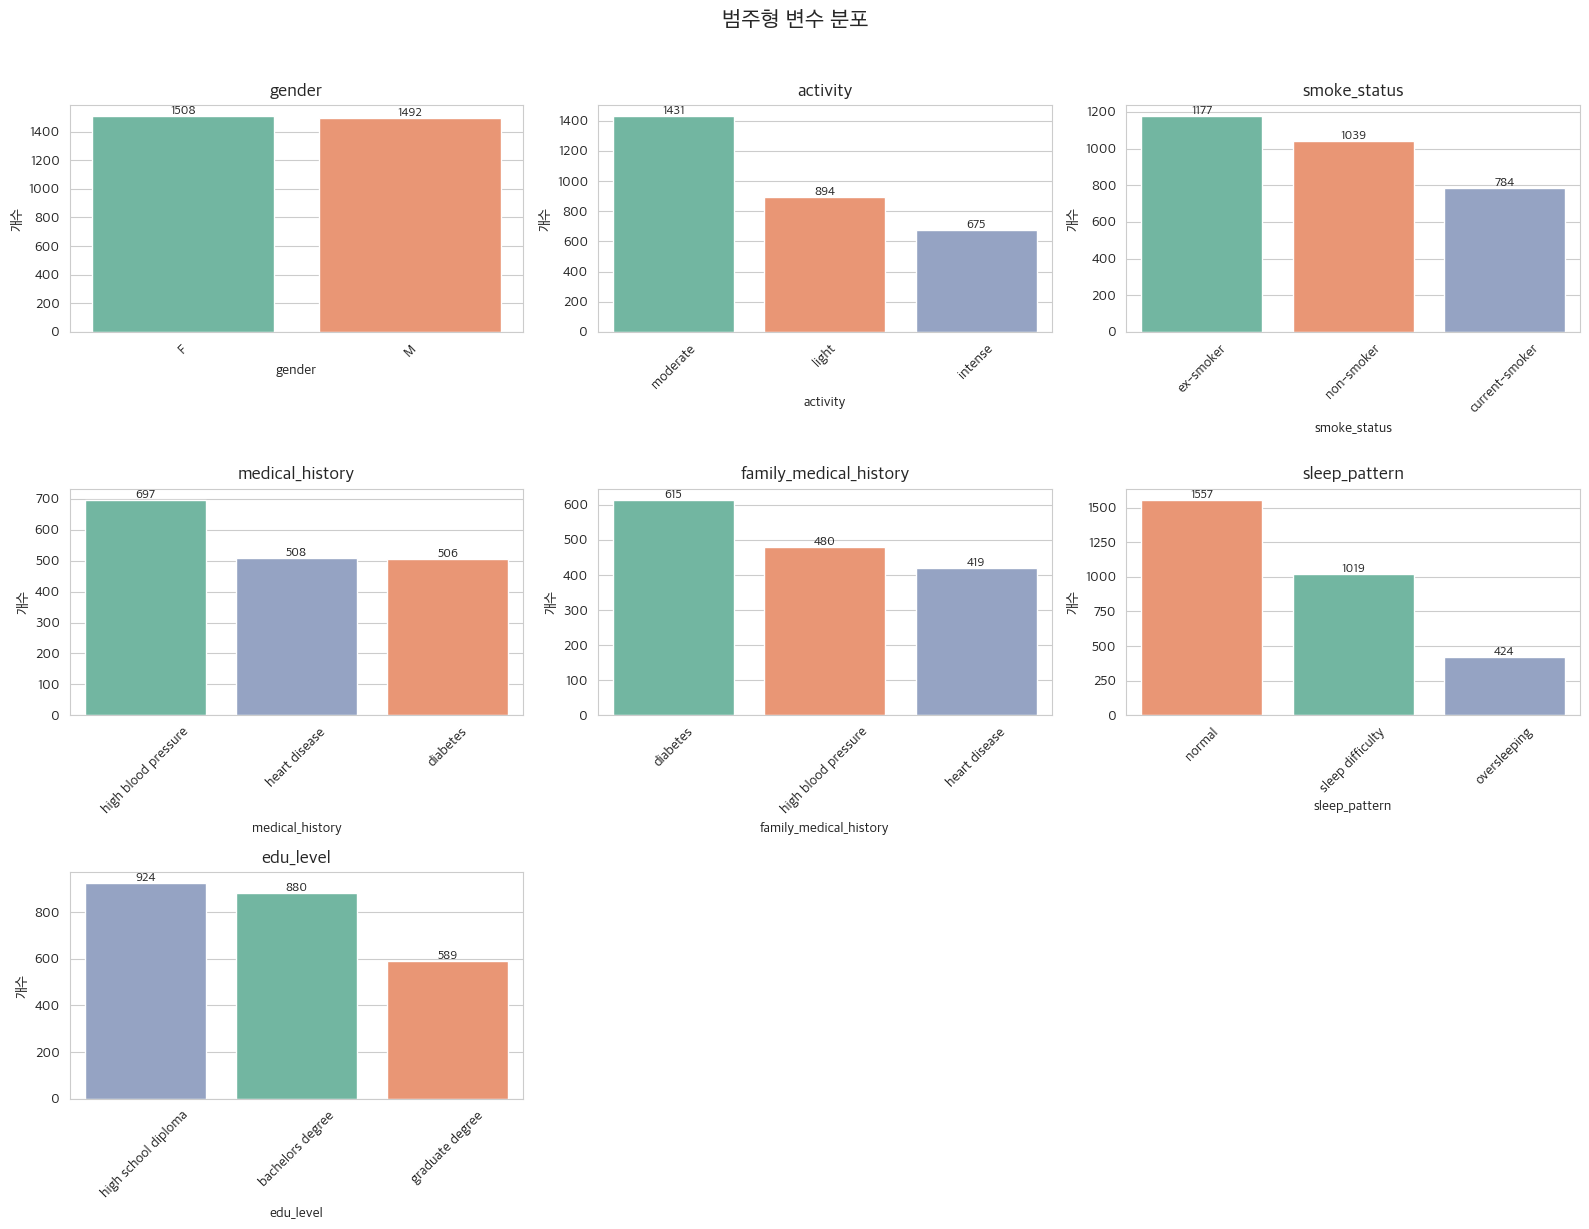

In [15]:
# 범주형 변수별 카운트 플롯
n_rows_cat = (len(cat_cols) + 2) // 3

fig, axes = plt.subplots(n_rows_cat, 3, figsize=(16, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 빈도순으로 정렬
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, hue=col, ax=axes[i], order=order,
                  palette='Set2', legend=False)
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_ylabel('개수')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 막대 위에 개수 표시
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('범주형 변수 분포', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 1-6. 타겟 변수(stress_score) 분석

우리가 예측해야 할 **stress_score**가 어떤 분포를 가지는지 확인합니다.  
이것이 회귀 문제인지, 분류 문제인지 감을 잡을 수 있습니다.

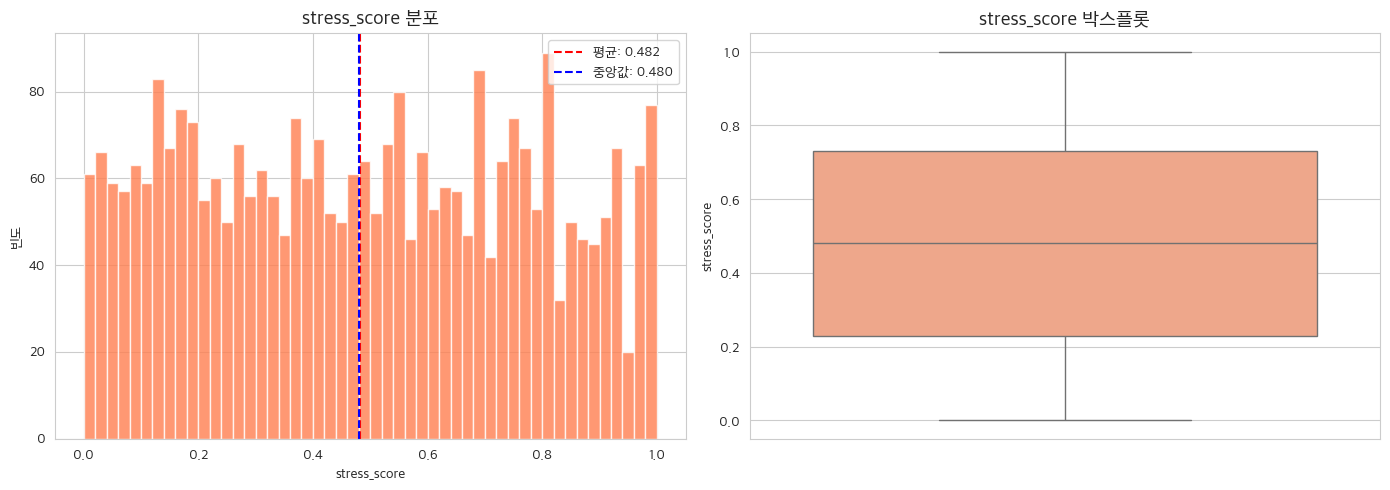

=== stress_score 기본 통계 ===
최솟값: 0.0
최댓값: 1.0
평균:   0.4821
중앙값: 0.4800
표준편차: 0.2883


In [16]:
target = config['features']['target']  # 'stress_score'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 히스토그램
axes[0].hist(train[target], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].axvline(train[target].mean(), color='red', linestyle='--', label=f'평균: {train[target].mean():.3f}')
axes[0].axvline(train[target].median(), color='blue', linestyle='--', label=f'중앙값: {train[target].median():.3f}')
axes[0].set_title('stress_score 분포', fontsize=14)
axes[0].set_xlabel('stress_score')
axes[0].set_ylabel('빈도')
axes[0].legend()

# (2) 박스플롯
sns.boxplot(data=train, y=target, ax=axes[1], color='lightsalmon')
axes[1].set_title('stress_score 박스플롯', fontsize=14)

plt.tight_layout()
plt.show()

# 기본 통계
print(f'=== stress_score 기본 통계 ===')
print(f'최솟값: {train[target].min()}')
print(f'최댓값: {train[target].max()}')
print(f'평균:   {train[target].mean():.4f}')
print(f'중앙값: {train[target].median():.4f}')
print(f'표준편차: {train[target].std():.4f}')

## 1-7. 변수 간 상관관계

수치형 변수들이 서로 얼마나 관련이 있는지 확인합니다.  
- **1에 가까우면**: 양의 상관관계 (하나가 올라가면 다른 것도 올라감)
- **-1에 가까우면**: 음의 상관관계 (하나가 올라가면 다른 것은 내려감)
- **0에 가까우면**: 관계 없음

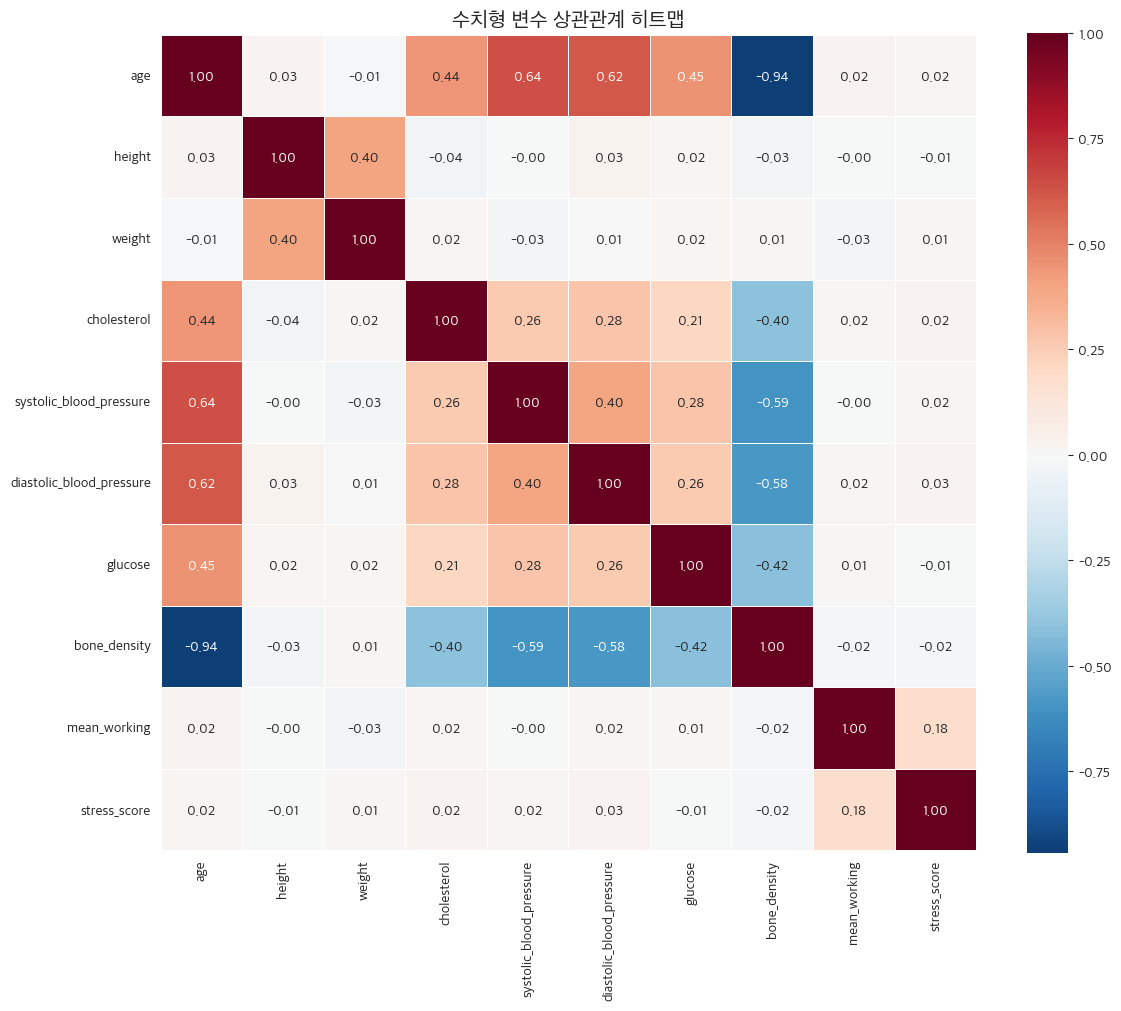

In [17]:
# 수치형 변수 + 타겟 상관관계 히트맵
corr_cols = num_cols + [target]
corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('수치형 변수 상관관계 히트맵', fontsize=15)
plt.tight_layout()
plt.show()

## 히트맵 분석
### 1차원 적 분석
- 타겟 변수 스트레스 점수(stress_score)와 비교하였을 때, 단순히 1차원적인 관계가 없다.
- 그나마 1주일당 평균 근로 시간(mean_working)이 0.18로 양의 상관관계를 가진다.

### 변수들 간의 분석
- 골밀도(bone_density)와 나이(age)가 -0.94로 서로 음의 상관관계를 가진다. -> 나이가 들수록 골밀도가 떨어진다.
- 혈압(systolic_blood_pressure, diastolic_blood_pressure) 2개의 모든 값이 나이(age)와 0.64, 0.62로 양의 상관관계를 가진다.

### 가능성있는 파생변수
- 키와 몸무게의 상관계수가 0.40으로 BMI 수치를 만들어본다.

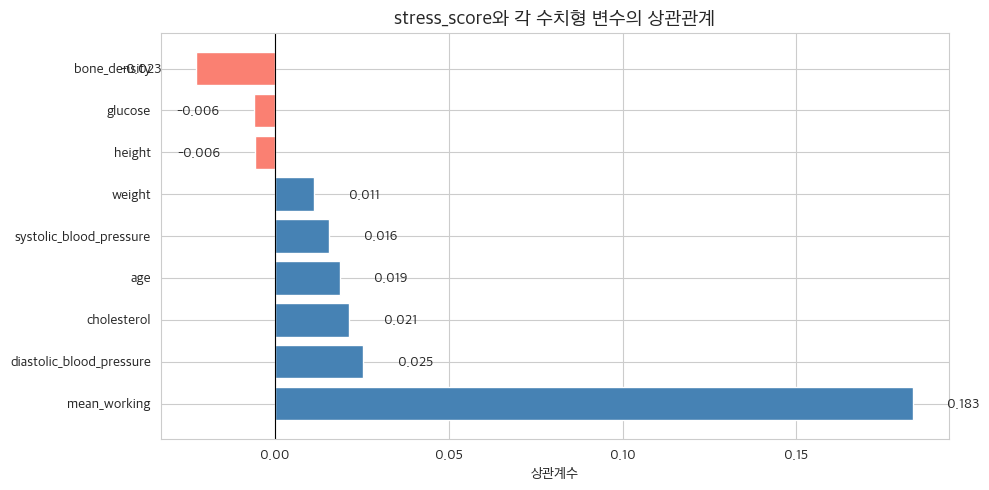

In [18]:
# 타겟(stress_score)과의 상관관계만 정렬해서 보기
target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_xlabel('상관계수')
ax.set_title('stress_score와 각 수치형 변수의 상관관계', fontsize=14)
ax.axvline(0, color='black', linewidth=0.8)

for i, val in enumerate(target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

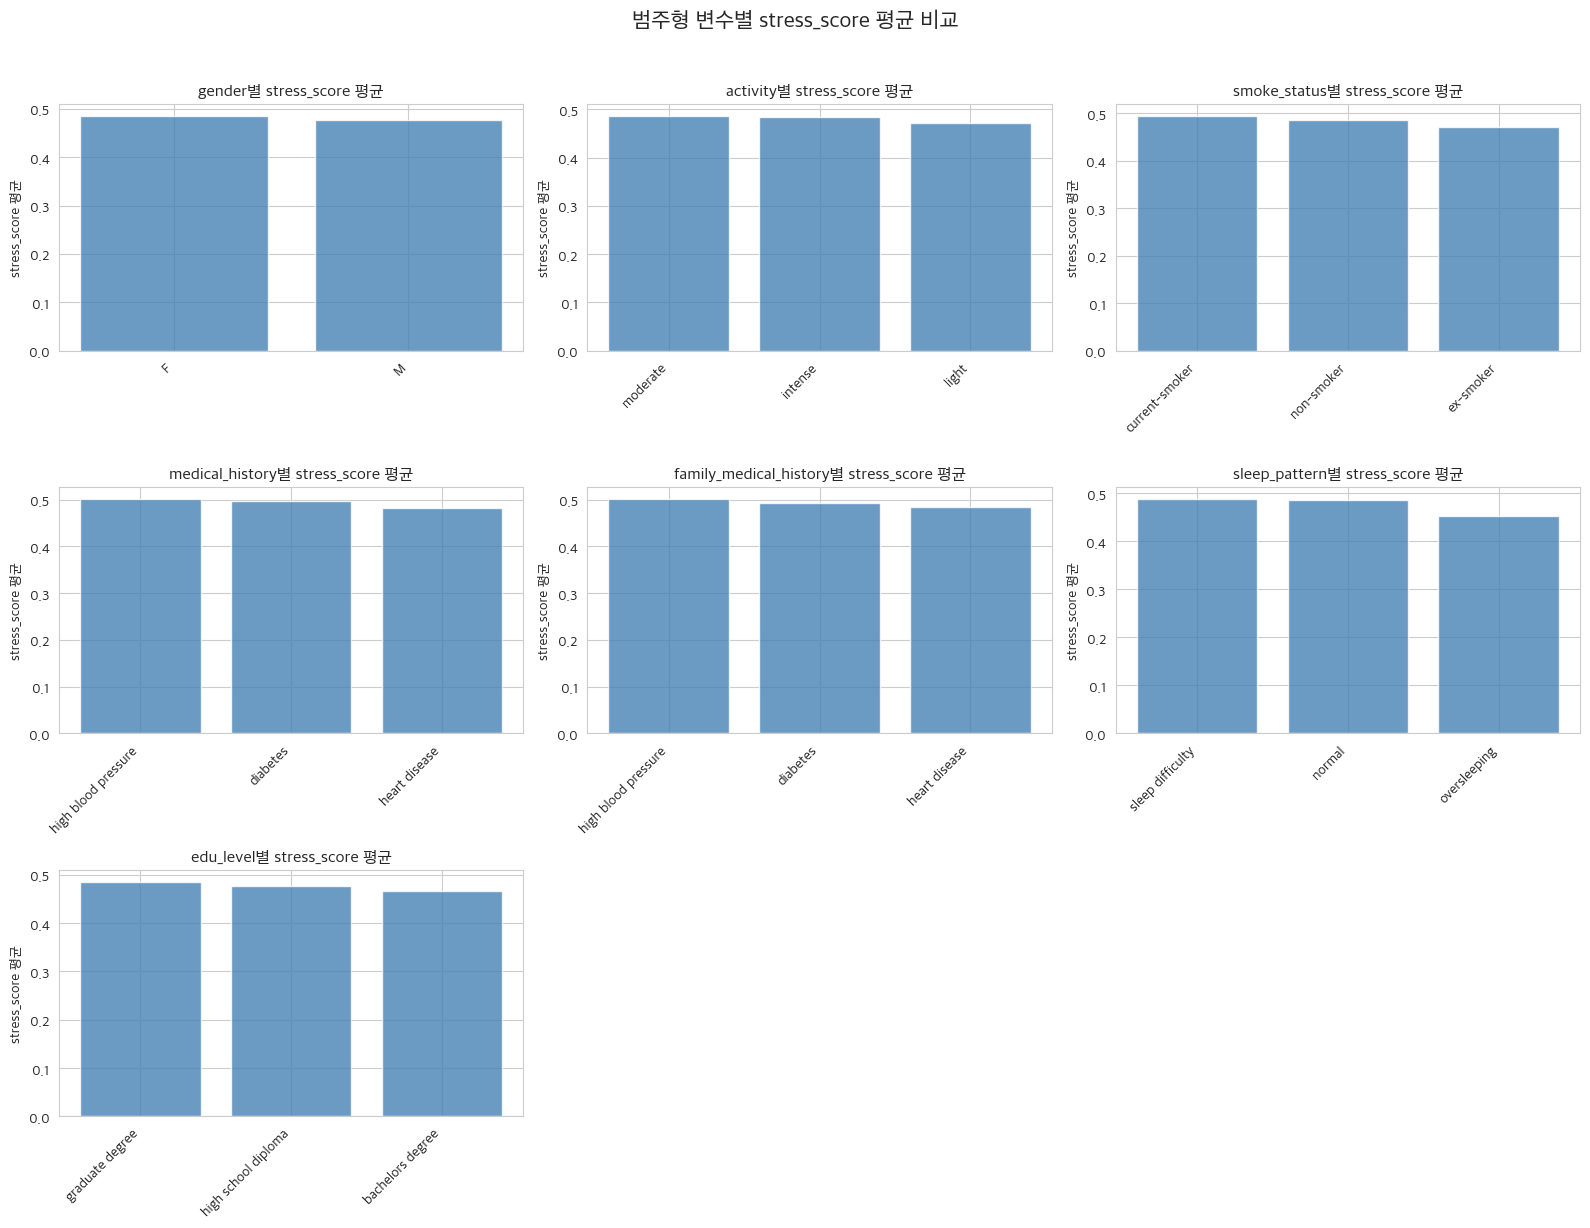

In [19]:
# 범주형 변수별 stress_score 평균 비교
fig, axes = plt.subplots(n_rows_cat, 3, figsize=(16, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 그룹별 평균 계산 후 정렬
    group_mean = train.groupby(col)[target].mean().sort_values(ascending=False)
    axes[i].bar(range(len(group_mean)), group_mean.values, color='steelblue', alpha=0.8)
    axes[i].set_xticks(range(len(group_mean)))
    axes[i].set_xticklabels(group_mean.index, rotation=45, ha='right')
    axes[i].set_title(f'{col}별 stress_score 평균', fontsize=12)
    axes[i].set_ylabel('stress_score 평균')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('범주형 변수별 stress_score 평균 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 범주형 막대 그래프 분석
### 전반적인 평준화
- 성별, 활동량, 학력 등은 대부분이 비슷하다.

### 유의미한 단서
- 수면패턴 : 과수면 그룹이 스트레스 평균이 가장 낮다
- 병력 : 고혈압 그룹이 스트레스 수치가 높다
- 흡연 여부 : 현재 흡연자 그룹이 스트레스가 높은 수치가 보인다.

## 1-8. EDA 요약

위 분석 결과를 바탕으로 2단계(전처리)에서 처리해야 할 사항을 정리합니다.

In [22]:
print('=' * 60)
print('EDA 요약 리포트')
print('=' * 60)
print()
print(f'[데이터 크기]')
print(f'  Train: {train.shape[0]:,}행 x {train.shape[1]}열')
print(f'  Test:  {test.shape[0]:,}행 x {test.shape[1]}열')
print()
print(f'[타겟 변수: stress_score]')
print(f'  범위: {train[target].min()} ~ {train[target].max()}')
print(f'  평균: {train[target].mean():.4f}')
print()
print(f'[결측치가 있는 컬럼]')
for col in train.columns:
    n_miss = train[col].isnull().sum()
    if n_miss > 0:
        pct = n_miss / len(train) * 100
        print(f'  {col}: {n_miss}건 ({pct:.1f}%)')

EDA 요약 리포트

[데이터 크기]
  Train: 3,000행 x 18열
  Test:  3,000행 x 17열

[타겟 변수: stress_score]
  범위: 0.0 ~ 1.0
  평균: 0.4821

[결측치가 있는 컬럼]
  medical_history: 1289건 (43.0%)
  family_medical_history: 1486건 (49.5%)
  edu_level: 607건 (20.2%)
  mean_working: 1032건 (34.4%)
